#### Query: (hand or gripper) and (manipulation or grasping or grip or skill)  
#### Years: 2019-2025 (6 Years)
#### Citation: 1+
#### Source: Google Scholar

In [18]:
# open json file
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

all_data = []
def open_json_file(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data



count_all=0
count_after_duplicates=0
count_after_arxiv_ieee_remove=0
all_articles_gs=[]
citations_gs=[]
years_gs=[]
titles_gs=[]
source_gs=[]
publisher_gs=[]

files_list = glob("data/data_*.json")
for file in files_list:
    data_gs=open_json_file(file)
    for i in data_gs["organic_results"]:
        #if "cited_by" in keys
        if "cited_by" in i["inline_links"].keys():
            title_gs = i["title"]
            count_all+=1
            # check if the article is already in the list
            if title_gs in titles_gs:
                continue
            count_after_duplicates+=1
            publisher=i["publication_info"]["summary"].split(" -")[-1][1:]
            # filter all arxiv and ieee articles
            if "arxiv" in publisher.lower() or "ieee" in publisher.lower():
                continue
            count_after_arxiv_ieee_remove+=1
            all_articles_gs.append(i)
            citations_gs.append(i["inline_links"]["cited_by"]["total"])
            try:
                years_gs.append(int(i["publication_info"]["summary"].split(" -")[-2][-4:]))
            except:
                years_gs.append(0)
                print("error")
            source_gs.append(i["publication_info"]["summary"].split(" -")[-2][:-6])
            publisher_gs.append(publisher)  
            titles_gs.append(title_gs)

error
error


In [19]:
count_all

1442

In [20]:
count_after_duplicates

1346

In [21]:
count_after_arxiv_ieee_remove

796

In [22]:
print("Overall Number of Articles: ",len(all_articles_gs))

Overall Number of Articles:  796


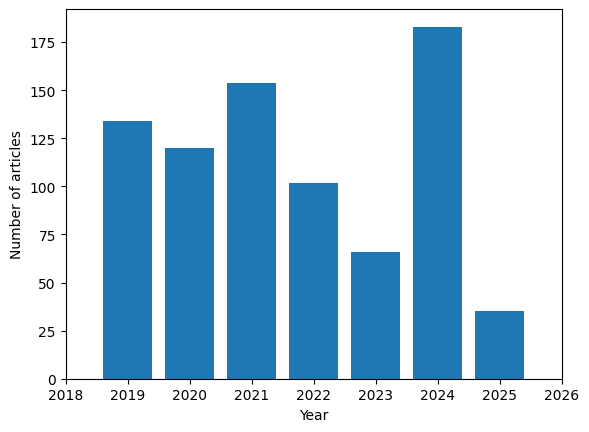

In [23]:
plt.bar(*np.unique(years_gs, return_counts=True), )
# set x-axis label
plt.xlabel('Year')
# set y-axis label
plt.ylabel('Number of articles')
plt.xlim(2018, 2026)
plt.show()

In [24]:
from scholarly import scholarly, ProxyGenerator

pg = ProxyGenerator()
success = pg.FreeProxies()
scholarly.use_proxy(pg)

articles_data_gs = []
articles_not_found_gs = []

for i in all_articles_gs:
    search_query = scholarly.search_pubs(i["title"])
    try :
        articles_data_gs.append(next(search_query))
    except:
        articles_not_found_gs.append(i)
        continue

KeyboardInterrupt: 

## Include IEEE Papers

In [27]:
# open json file
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

all_data_ieee = []
def open_json_file(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

all_articles_ieee=[]

list_files=glob("../IEEE-Xplore-API_p3/data/data_*.json")
for file in list_files:
    data_ieee=open_json_file(file)
    for j in data_ieee["articles"]:
        all_articles_ieee.append(j)

keywords_0=['hand', 'gripper']
keywords_1=['manipulation', 'grasping' , 'grip', 'skill']

keywords_used=[]
terms_used=[]
articles_filtered_ieee = []
articles_filtered_titles_ieee = []
for article in all_articles_ieee:
    if "citing_paper_count" in article.keys():
        if article["citing_paper_count"] > 0:
            # if keywords in index_terms
            flag_0=False
            flag_1=False
            all_terms=[]
            for j in article["index_terms"].values():
                terms=[x.lower() for x in j["terms"]]
                all_terms+=terms  # ieee and authors terms
            all_terms=np.unique(all_terms)
            for l in keywords_0:
                for k in all_terms:
                    if l in k:
                        flag_0=True
                        keywords_used.append(l)
                        terms_used.append(k)
                        break    
            for l in keywords_1:
                for k in all_terms:
                    if l in k:
                        flag_1=True
                        keywords_used.append(l)
                        terms_used.append(k)
                        break
            if flag_0 and flag_1:
                articles_filtered_ieee.append(article)
                articles_filtered_titles_ieee.append(article["title"])

terms_used=np.unique(terms_used)

In [28]:
len(all_articles_ieee)

5321

In [31]:
len(articles_filtered_ieee)

891

In [32]:
# be sure that all IEEE articles are not in the GS list based on naive name matching
article_found_ieee=[]
article_not_found_ieee=[]
for i, article_ieee in zip(articles_filtered_titles_ieee, articles_filtered_ieee):
    i = i.lower()
    flag_found=False
    for j in all_articles_gs:
        if i in j["title"].lower():
            flag_found=True
            # update abstract
            j["snippet"] = article_ieee["abstract"]
            break 
    if flag_found:
        article_found_ieee.append(article_ieee)        
    else: 
        article_not_found_ieee.append(article_ieee)

In [36]:
len(articles_filtered_ieee)+len(all_articles_gs)

1687

In [ ]:
# save all_articles to csv file

import csv
with open('articles_gs_ieee_new_filtered.csv', mode='w') as file:
    writer = csv.writer(file, delimiter=';', quotechar='"', quoting=csv.QUOTE_MINIMAL)
    writer.writerow(["Title", "Citations", "Year", "Source","Publisher", "Snippet", "URL","Keywords", "Name",	"Relevant (Yes/No)"])
    for i in range(len(all_articles_gs)):
        if "link" not in all_articles_gs[i].keys():
            writer.writerow([all_articles_gs[i]["title"], citations_gs[i], years_gs[i], source_gs[i], publisher_gs[i] ,  all_articles_gs[i]["snippet"], "", "", "", ""])
        else:
            writer.writerow([all_articles_gs[i]["title"], citations_gs[i], years_gs[i], source_gs[i], publisher_gs[i], all_articles_gs[i]["snippet"], all_articles_gs[i]["link"], "", "", ""])
    
    for i in articles_filtered_ieee:
        all_terms=[]
        for j in i["index_terms"].values():
            terms=[x.lower() for x in j["terms"]]
            all_terms+=terms  # ieee and authors terms
        all_terms=np.unique(all_terms)
        writer.writerow([i["title"], i["citing_paper_count"], i["publication_year"], i["publication_title"],"IEEE", i["abstract"], i["pdf_url"], all_terms, "", "Yes"])
